# Importing Required Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import math
from statsmodels.stats.diagnostic import acorr_ljungbox
import seaborn as sns

# Data Loading and Initial Exploration

In [61]:
# --------------- Load data ---------------
file_path = "Toys Sales.xlsx"
df = pd.read_excel(file_path, sheet_name="Toys Sales", engine="openpyxl")

# Trim whitespace from column names
df.columns = df.columns.str.strip()

# Parse Date: expects format YYYY-MM, convert to period/month index
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
df = df.sort_values('Date').reset_index(drop=True)

# Set monthly DateTimeIndex (period start)
df.set_index('Date', inplace=True)
df.index = pd.DatetimeIndex(df.index).to_period('M').to_timestamp()  # ensure monthly freq

# Series
ts = df['Toys Sales'].asfreq('MS')  # Month Start frequency

# --- 1️⃣ Basic info ---
print("Data Overview:\n", ts.head())
print("\nData Summary:\n", ts.describe())
print("\nMissing Values:\n", ts.isnull().sum())

Data Overview:
 Date
2006-01-01    182.7
2006-02-01    145.2
2006-03-01    182.1
2006-04-01    158.7
2006-05-01    141.6
Freq: MS, Name: Toys Sales, dtype: float64

Data Summary:
 count    228.000000
mean     158.647807
std       21.786733
min      114.600000
25%      143.000000
50%      153.900000
75%      172.025000
max      217.800000
Name: Toys Sales, dtype: float64

Missing Values:
 0


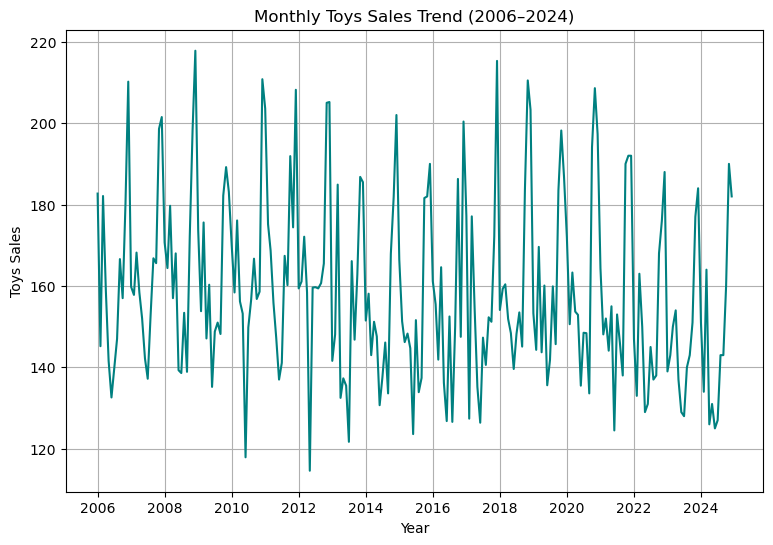

C:\Users\lakshmi priyanka\AppData\Local\Temp\ipykernel_20704\646391560.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Toys Sales', data=df, order=month_order, palette="Set2")


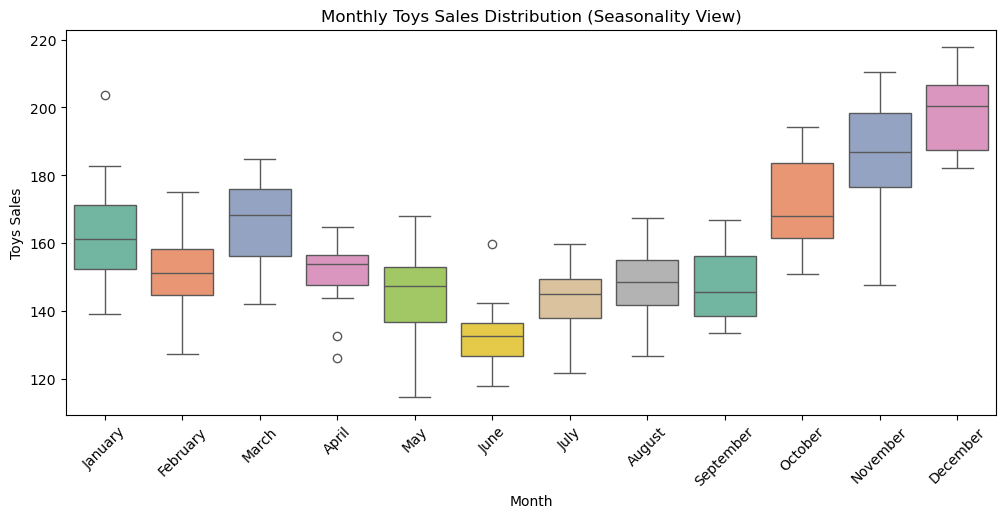

In [63]:
# --- Line plot (overall trend) ---
plt.figure(figsize=(9,6))
plt.plot(ts.index, ts, color='teal')
plt.title("Monthly Toys Sales Trend (2006–2024)")
plt.xlabel("Year")
plt.ylabel("Toys Sales")
plt.grid(True)
plt.show()


# --- Boxplot: seasonal variation across months ---
# Create a 'Month' column for grouping
df['Month'] = df.index.month_name()

# Optional: to keep months in calendar order (not alphabetical)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12,5))
sns.boxplot(x='Month', y='Toys Sales', data=df, order=month_order, palette="Set2")
plt.title("Monthly Toys Sales Distribution (Seasonality View)")
plt.xlabel("Month")
plt.ylabel("Toys Sales")
plt.xticks(rotation=45)
plt.show()


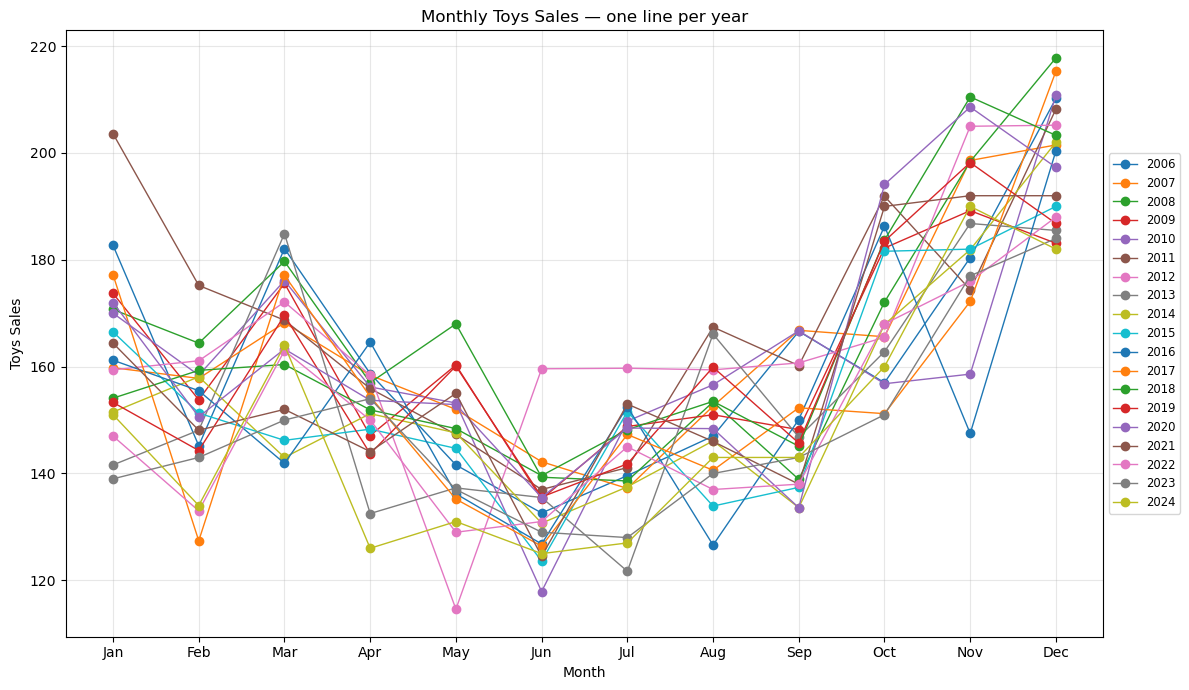

In [64]:
# Prepare a wide DataFrame where columns = years, rows = months Jan..Dec
df_plot = ts.copy()
df_plot = df_plot.to_frame()
df_plot['Year'] = df_plot.index.year
df_plot['Month'] = df_plot.index.month

wide = df_plot.pivot(index='Month', columns='Year', values='Toys Sales').sort_index()
wide.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12,7))
for year in wide.columns:
    plt.plot(wide.index, wide[year], marker='o', label=str(year), linewidth=1)
plt.title('Monthly Toys Sales — one line per year')
plt.xlabel('Month')
plt.ylabel('Toys Sales')
plt.legend(loc='center left', bbox_to_anchor=(1,0.5), ncol=1, fontsize='small')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Decomposition

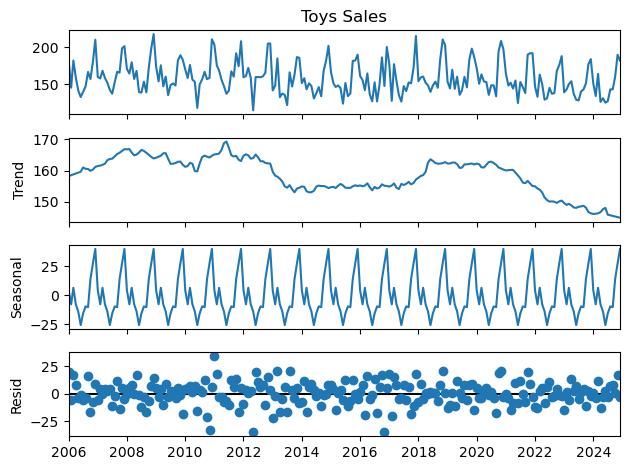

In [65]:
decomp = seasonal_decompose(ts, model='additive', period=12, extrapolate_trend='freq')
decomp.plot()
plt.tight_layout()
plt.show()

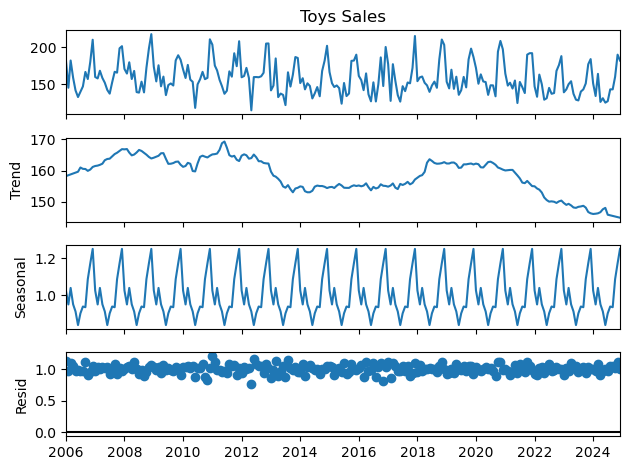

In [67]:
decomp = seasonal_decompose(ts, model='multiplicative', period=12, extrapolate_trend='freq')
decomp.plot()
plt.tight_layout()
plt.show()

# ACF and PACF Plotting

<Figure size 1200x400 with 0 Axes>

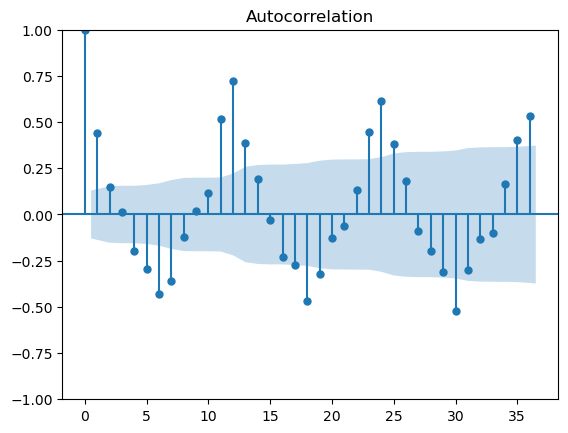

<Figure size 1200x400 with 0 Axes>

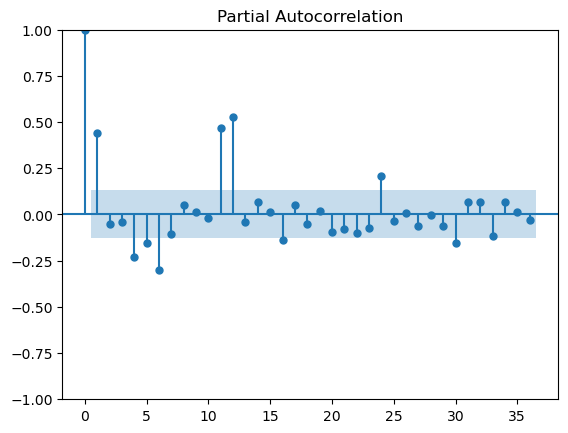

In [69]:
# ACF & PACF
plt.figure(figsize=(12,4))
plot_acf(ts.dropna(), lags=36, alpha=0.05)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(ts.dropna(), lags=36, alpha=0.05, method='ywm')
plt.show()

# Deseasonalizing the Data

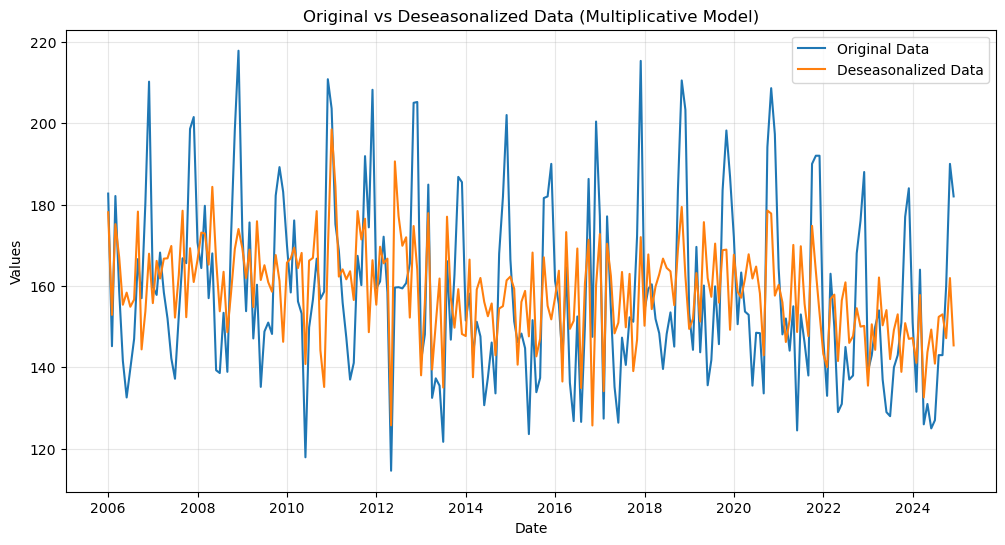

Date
2006-01-01    178.106659
2006-02-01    152.895989
2006-03-01    175.189408
2006-04-01    167.025657
2006-05-01    155.380005
2006-06-01    158.360633
2006-07-01    154.890413
2006-08-01    156.660168
2006-09-01    178.275126
2006-10-01    144.413585
2006-11-01    153.758194
2006-12-01    167.925480
Freq: MS, dtype: float64


In [70]:
# Perform multiplicative decomposition (use entire series)
decomp = seasonal_decompose(ts, model='multiplicative', period=12, extrapolate_trend='freq')

# Extract seasonal component
seasonal = decomp.seasonal

# Deseasonalize: divide original data by its seasonal component
deseasonalized = ts / seasonal

# Plot original vs deseasonalized data
plt.figure(figsize=(12,6))
plt.plot(ts, label='Original Data', color='C0')
plt.plot(deseasonalized, label='Deseasonalized Data', color='C1')
plt.title('Original vs Deseasonalized Data (Multiplicative Model)')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Optional: display first few deseasonalized values
print(deseasonalized.head(12))

# Test for Stationary - ADF Test

In [75]:
# Perform ADF test on deseasonalized data
adf_result = adfuller(deseasonalized.dropna())  # dropna() to remove missing values

# Display results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations Used:", adf_result[3])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

# Interpretation
if adf_result[1] <= 0.05:
    print("\n✅ The deseasonalized series is stationary (reject H0).")
else:
    print("\n❌ The deseasonalized series is non-stationary (fail to reject H0).")

ADF Statistic: -0.9730518603097058
p-value: 0.7629657074757603
Number of Lags Used: 11
Number of Observations Used: 216
Critical Values:
   1%: -3.4609922013325267
   5%: -2.875015740963014
   10%: -2.5739524288408777

❌ The deseasonalized series is non-stationary (fail to reject H0).


# Differencing

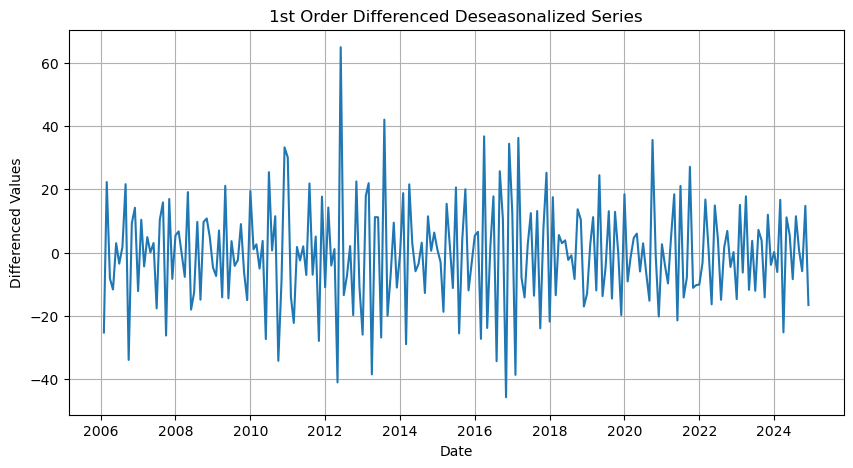

ADF Statistic: -8.506429708247941
p-value: 1.1994321804193305e-13
Number of Lags Used: 10
Number of Observations Used: 216
Critical Values:
   1%: -3.4609922013325267
   5%: -2.875015740963014
   10%: -2.5739524288408777

✅ The differenced series is stationary (reject H0).


In [81]:
# ------------------ 1️⃣ First-order differencing ------------------
ts_diff1 = deseasonalized.diff(1).dropna()  # difference of order 1

# ------------------ 2️⃣ Plot the differenced data ------------------
plt.figure(figsize=(10,5))
plt.plot(ts_diff1)
plt.title('1st Order Differenced Deseasonalized Series')
plt.xlabel('Date')
plt.ylabel('Differenced Values')
plt.grid(True)
plt.show()

# ------------------ 3️⃣ Perform ADF test on differenced series ------------------
adf_result_diff1 = adfuller(ts_diff1)

# Display results
print("ADF Statistic:", adf_result_diff1[0])
print("p-value:", adf_result_diff1[1])
print("Number of Lags Used:", adf_result_diff1[2])
print("Number of Observations Used:", adf_result_diff1[3])
print("Critical Values:")
for key, value in adf_result_diff1[4].items():
    print(f"   {key}: {value}")

# Interpretation
if adf_result_diff1[1] <= 0.05:
    print("\n✅ The differenced series is stationary (reject H0).")
else:
    print("\n❌ The differenced series is still non-stationary (fail to reject H0).")

# ACF and PACF Plots After Differencing

<Figure size 1200x400 with 0 Axes>

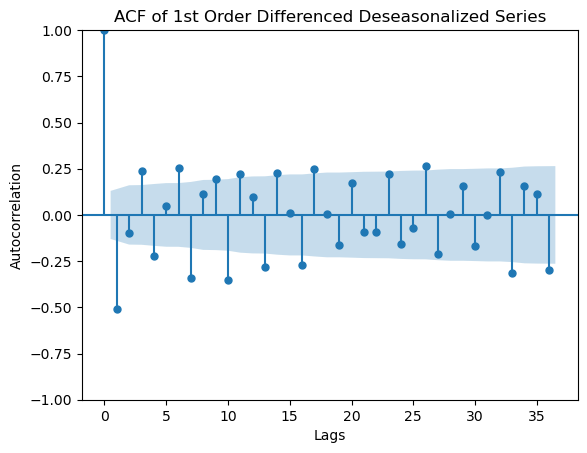

<Figure size 1200x400 with 0 Axes>

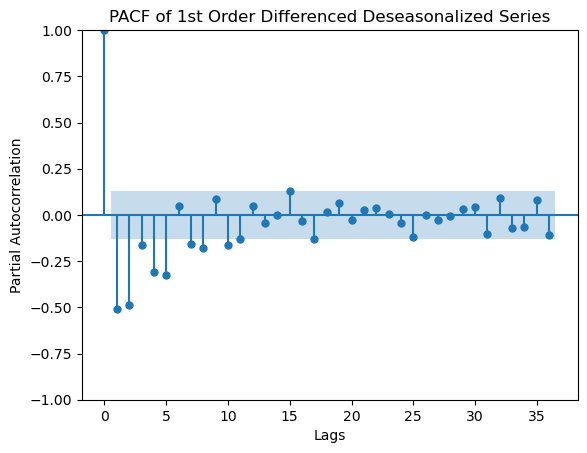

In [83]:
# --- ACF Plot ---
plt.figure(figsize=(12,4))
plot_acf(ts_diff1.dropna(), lags=36)
plt.title('ACF of 1st Order Differenced Deseasonalized Series')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

# --- PACF Plot ---
plt.figure(figsize=(12,4))
plot_pacf(ts_diff1.dropna(), lags=36, method='ywm')
plt.title('PACF of 1st Order Differenced Deseasonalized Series')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

# Splitting of Train and Test Data

In [35]:
# Use last 12 months as test (standard for monthly seasonality)
forecast_horizon = 12
train = ts[:-forecast_horizon]a
test  = ts[-forecast_horizon:]
print("Train:", train.index.min(), "to", train.index.max())
print("Test:", test.index.min(), "to", test.index.max())

Train: 2006-01-01 00:00:00 to 2023-12-01 00:00:00
Test: 2024-01-01 00:00:00 to 2024-12-01 00:00:00


# ARIMA Model (Before Deseasonalizing)

                               SARIMAX Results                                
Dep. Variable:             Toys Sales   No. Observations:                  216
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -946.513
Date:                Wed, 29 Oct 2025   AIC                           1899.025
Time:                        11:04:53   BIC                           1909.137
Sample:                    01-01-2006   HQIC                          1903.111
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4386      0.061      7.237      0.000       0.320       0.557
ma.L1         -0.9996      0.415     -2.408      0.016      -1.813      -0.186
sigma2       382.4580    171.758      2.227      0.0

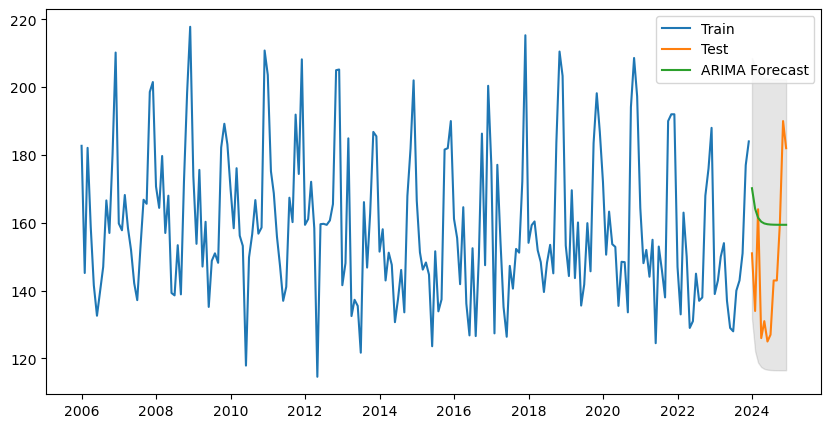

In [42]:
from sklearn.metrics import mean_absolute_percentage_error
import math
import matplotlib.pyplot as plt

# Fit ARIMA(1,1,1) as baseline
model_arima = ARIMA(train, order=(1,1,1))
res_arima = model_arima.fit()
print(res_arima.summary())

# Forecast
pred_arima = res_arima.get_forecast(steps=forecast_horizon)
fc_arima = pred_arima.predicted_mean
conf_int_arima = pred_arima.conf_int()

# Evaluate
rmse_arima = math.sqrt(mean_squared_error(test, fc_arima))
mape_arima = mean_absolute_percentage_error(test, fc_arima) * 100
print("ARIMA RMSE:", rmse_arima)
print(f"ARIMA MAPE: {mape_arima:.2f}%")

# Plot
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(fc_arima.index, fc_arima, label='ARIMA Forecast')
plt.fill_between(fc_arima.index, conf_int_arima.iloc[:,0], conf_int_arima.iloc[:,1], color='k', alpha=0.1)
plt.legend(); plt.show()

# ARIMA Model (After Deseasonalizing)

Train period: 2006-01-01 00:00:00 to 2023-12-01 00:00:00
Test period : 2024-01-01 00:00:00 to 2024-12-01 00:00:00

Seasonal factors by month (train):
 Date
1     1.026195
2     0.952270
3     1.035771
4     0.955986
5     0.913376
6     0.837626
7     0.903707
8     0.936790
9     0.932813
10    1.087342
11    1.166200
12    1.251922
Name: seasonal, dtype: float64

ARIMA (on deseasonalized train) summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  216
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -825.613
Date:                Wed, 29 Oct 2025   AIC                           1657.226
Time:                        16:23:21   BIC                           1667.338
Sample:                    01-01-2006   HQIC                          1661.311
                         - 12-01-2023                                         
Covariance Type:                  opg 

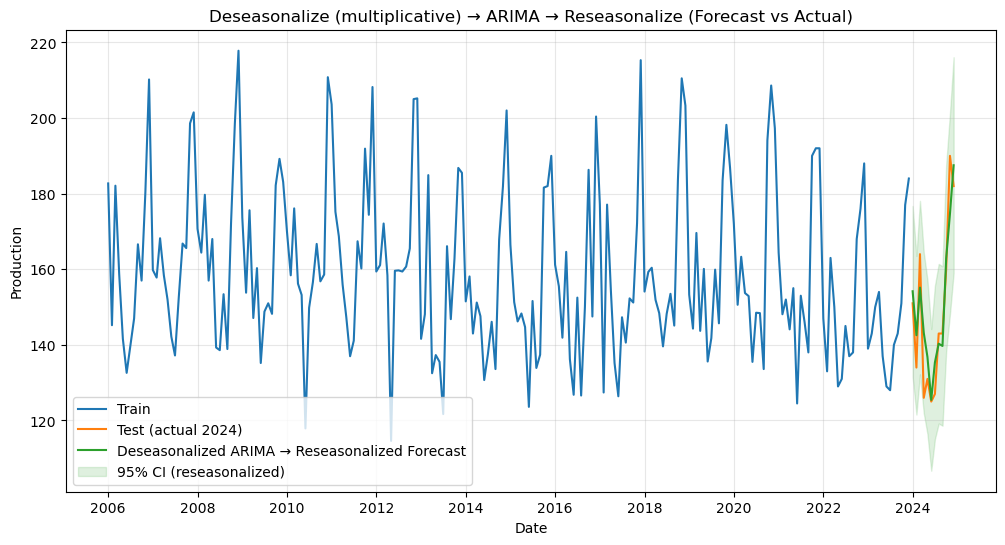


Actual vs Forecast (first rows):
             Actual    Forecast    Lower_95    Upper_95
2024-01-01   151.0  154.183284  131.643476  176.723092
2024-02-01   134.0  142.548158  121.578863  163.517454
2024-03-01   164.0  155.144950  132.199718  178.090182
2024-04-01   126.0  143.179013  121.935733  164.422293
2024-05-01   131.0  136.799675  116.432418  157.166932
2024-06-01   125.0  125.453991  106.712471  144.195510
2024-07-01   127.0  135.351169  115.062716  155.639621
2024-08-01   143.0  140.306145  119.204333  161.407958
2024-09-01   143.0  139.710492  118.628161  160.792824
2024-10-01   160.0  162.854779  138.198526  187.511033
2024-11-01   190.0  174.665555  148.134081  201.197028
2024-12-01   182.0  187.504479  158.929630  216.079327


In [85]:
# --- Deseasonalize (multiplicative), fit ARIMA on deseasonalized train, reseasonalize forecasts ---

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period :", test.index.min(), "to", test.index.max())

# 1) Multiplicative decomposition on TRAIN only (to avoid leakage)
decomp = seasonal_decompose(train, model='multiplicative', period=12, extrapolate_trend='freq')
seasonal_train = decomp.seasonal        # seasonal factors for train index
trend_train = decomp.trend
resid_train = decomp.resid

# Show seasonal pattern by month (average)
seasonal_by_month = seasonal_train.groupby(seasonal_train.index.month).mean()
seasonal_by_month = seasonal_by_month.sort_index()  # index 1..12
print("\nSeasonal factors by month (train):\n", seasonal_by_month)

# 2) Deseasonalize TRAIN (divide by seasonal factors)
deseasonalized_train = train / seasonal_train

# 3) Optionally confirm stationarity or difference as earlier (we'll fit ARIMA(1,1,1) per your workflow)
# Fit ARIMA on deseasonalized_train
arima_order = (1,1,1)
model_ds = ARIMA(deseasonalized_train, order=arima_order)
res_ds = model_ds.fit()
print("\nARIMA (on deseasonalized train) summary:")
print(res_ds.summary())

# 4) Forecast deseasonalized values for the horizon
fc_deseasonalized = res_ds.get_forecast(steps=forecast_horizon)
fc_ds_mean = fc_deseasonalized.predicted_mean
fc_ds_ci = fc_deseasonalized.conf_int(alpha=0.05)   # lower/upper for deseasonalized forecasts

# Create forecast index for 2024 months
fc_index = pd.date_range(start=test.index[0], periods=forecast_horizon, freq='MS')

fc_ds_mean.index = fc_index
fc_ds_ci.index = fc_index

# 5) Reseasonalize forecasts: multiply deseasonalized forecast by seasonal factor for corresponding month
# Build a seasonal factor series for forecast months by mapping month -> seasonal_by_month
seasonal_factors_forecast = pd.Series(
    [seasonal_by_month.loc[d.month] for d in fc_index],
    index=fc_index
)

fc_seasonalized_mean = fc_ds_mean * seasonal_factors_forecast
fc_seasonalized_lower = fc_ds_ci.iloc[:,0] * seasonal_factors_forecast
fc_seasonalized_upper = fc_ds_ci.iloc[:,1] * seasonal_factors_forecast

# 6) Evaluate: compare fc_seasonalized_mean with test
rmse = math.sqrt(mean_squared_error(test, fc_seasonalized_mean))
mape = mean_absolute_percentage_error(test, fc_seasonalized_mean) * 100

print(f"\nDeseasonalize → ARIMA{arima_order} → Reseasonalized forecast results:")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

# 7) Plot: history, train, test, reseasonalized forecast with CI
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train', color='C0')
plt.plot(test.index, test, label='Test (actual 2024)', color='C1')
plt.plot(fc_seasonalized_mean.index, fc_seasonalized_mean, label='Deseasonalized ARIMA → Reseasonalized Forecast', color='C2')

# Plot confidence interval ribbon
plt.fill_between(fc_seasonalized_mean.index,
                 fc_seasonalized_lower,
                 fc_seasonalized_upper,
                 color='C2', alpha=0.15, label='95% CI (reseasonalized)')

plt.title('Deseasonalize (multiplicative) → ARIMA → Reseasonalize (Forecast vs Actual)')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8) Optionally print a small table with actual vs forecast
comp = pd.DataFrame({
    'Actual': test,
    'Forecast': fc_seasonalized_mean,
    'Lower_95': fc_seasonalized_lower,
    'Upper_95': fc_seasonalized_upper
})
print("\nActual vs Forecast (first rows):\n", comp.head(12))

# SARIMA Model

                                     SARIMAX Results                                      
Dep. Variable:                         Toys Sales   No. Observations:                  216
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -749.412
Date:                            Wed, 29 Oct 2025   AIC                           1508.823
Time:                                    11:04:54   BIC                           1525.032
Sample:                                01-01-2006   HQIC                          1515.390
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1568      0.075     -2.104      0.035      -0.303      -0.011
ma.L1         -0.9053      0.042   

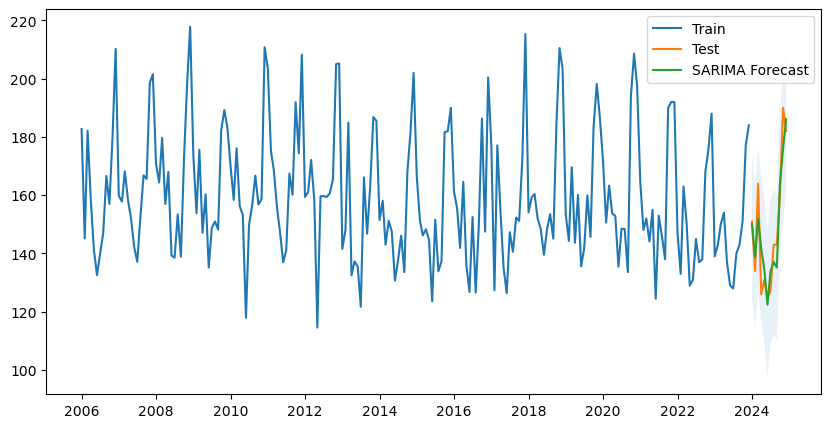

In [44]:
from sklearn.metrics import mean_absolute_percentage_error
import math
import matplotlib.pyplot as plt

# Fit SARIMA model
model_sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                       enforce_stationarity=False, enforce_invertibility=False)
res_sarima = model_sarima.fit(disp=False)
print(res_sarima.summary())

# Forecast
fc_sarima = res_sarima.get_forecast(steps=forecast_horizon)
pred_sarima = fc_sarima.predicted_mean
conf_sarima = fc_sarima.conf_int()

# Evaluate
rmse_sarima = math.sqrt(mean_squared_error(test, pred_sarima))
mape_sarima = mean_absolute_percentage_error(test, pred_sarima) * 100
print("SARIMA RMSE:", rmse_sarima)
print(f"SARIMA MAPE: {mape_sarima:.2f}%")

# Plot
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(pred_sarima.index, pred_sarima, label='SARIMA Forecast')
plt.fill_between(pred_sarima.index, conf_sarima.iloc[:,0], conf_sarima.iloc[:,1], alpha=0.1)
plt.legend(); plt.show()

# Holt-Winters Multiplicative Model (TES) 

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


Holt-Winters (multiplicative) RMSE: 10.257361547884987
Holt-Winters (multiplicative) MAPE: 5.12%


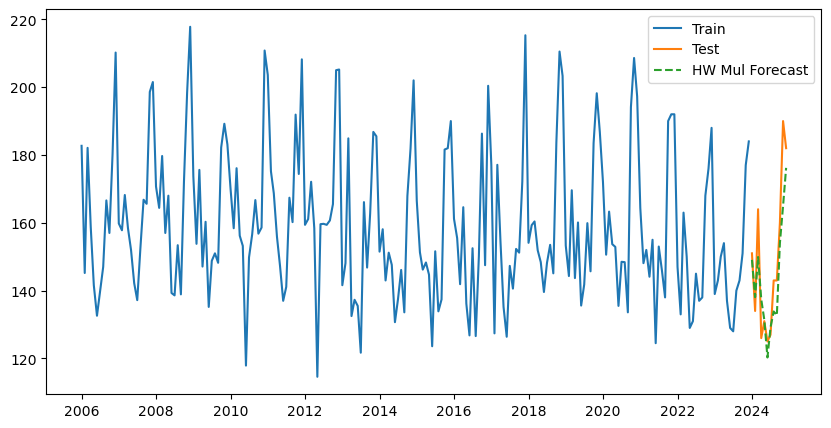

In [89]:
# Multiplicative seasonal Holt-Winters (if variance increases with level)
hw_mul = ExponentialSmoothing(train, trend='mul', seasonal='mul', seasonal_periods=12,
                              initialization_method="estimated").fit()
pred_hw_mul = hw_mul.forecast(forecast_horizon)
rmse_hw_mul = math.sqrt(mean_squared_error(test, pred_hw_mul))
mape_hw_mul = mean_absolute_percentage_error(test, pred_hw_mul) * 100
print("Holt-Winters (multiplicative) RMSE:", rmse_hw_mul)
print(f"Holt-Winters (multiplicative) MAPE: {mape_hw_mul:.2f}%")

# Plot best of the two
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(pred_hw_mul.index, pred_hw_mul, label='HW Mul Forecast', linestyle='--')
plt.legend(); plt.show()